# Teoría de Juegos y Dinámicas Poblacionales en el Ciclismo
## El ataque en etapas planas como juego Hawk-Dove

---

En una carrera de ciclismo plana, el instante en que alguien decide atacar concentra toda la tensión estratégica de la etapa. La decisión no es individual: el atacante evalúa si el pelotón responderá, y el pelotón evalúa si gastar energía persiguiendo vale la pena. Este notebook modela esa interacción desde dos perspectivas complementarias:

1. **Teoría de juegos clásica**: equilibrios de Nash del juego Hawk-Dove asimétrico de dos jugadores (atacante vs. pelotón).
2. **Dinámicas poblacionales**: cómo evolucionan las estrategias en una población grande de ciclistas a través de protocolos de revisión (replicador, Smith, Logit) derivados desde las mean dynamics.

El **atacante** elige entre atacar (*Hawk*) o quedarse en el pelotón (*Dove*). El **pelotón** elige entre perseguir (*Hawk*) o dejar ir (*Dove*). El único costo modelado es energético: atacar y perseguir gastan watts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.integrate import solve_ivp
from scipy.linalg import expm
from numpy.linalg import eigvals
from itertools import product
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'font.size': 11,
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


---
## Parte 1: Construcción de las matrices de pago

### 1.1 Parámetros del modelo

| Símbolo | Nombre | Interpretación ciclística |
|---------|--------|---------------------------|
| $V$ | Beneficio de ganar la etapa | Tiempo ganado, puntos, clasificación |
| $C_a$ | Costo energético del atacante | Watts jalando solo en la fuga |
| $C_p$ | Costo energético del pelotón | Watts en persecución colectiva (dividido entre $n$ ciclistas) |
| $\gamma$ | Factor de retención | Fracción de $V$ que el atacante conserva si es neutralizado |

$C_p < C_a$ porque el pelotón reparte el esfuerzo de persecución entre varios ciclistas.

### 1.2 Matrices de pago asimétricas

El juego es **asimétrico**: los dos jugadores tienen roles distintos, costos distintos y por tanto matrices de pago separadas $A$ (atacante) y $B$ (pelotón).

| | Pelotón Hawk (persigue) | Pelotón Dove (deja ir) |
|--|--|--|
| **Atacante Hawk (ataca)** | $A_{00} = \gamma V - C_a$, $B_{00} = V - C_p$ | $A_{01} = V - C_a$, $B_{01} = 0$ |
| **Atacante Dove (se queda)** | $A_{10} = 0$, $B_{10} = -C_p$ | $A_{11} = V/2$, $B_{11} = V/2$ |

In [2]:
# ── Parámetros del modelo ──────────────────────────────────────────────────
V     = 10.0   # beneficio de ganar la etapa
Ca    = 4.0    # costo energético del atacante (jala solo)
Cp    = 2.0    # costo energético del pelotón (persecución compartida)
gamma = 0.3    # fracción de V que retiene el atacante si es neutralizado

assert Ca > Cp, "Por diseño: el atacante siempre gasta más que el pelotón."
assert 0 < gamma < 1

# Estrategias: 0 = Hawk, 1 = Dove
A = np.array([
    [gamma*V - Ca,  V - Ca],   # Atacante: H vs H, H vs D
    [0,             V/2   ],   # Atacante: D vs H, D vs D
])
B = np.array([
    [V - Cp,   0  ],   # Pelotón: vs H, vs D (atacante=H)
    [-Cp,      V/2],   # Pelotón: vs H, vs D (atacante=D)
])

labels_atac    = ['Hawk (ataca)',    'Dove (se queda)']
labels_peloton = ['Hawk (persigue)', 'Dove (deja ir)' ]

print(f"Parámetros: V={V}  Ca={Ca}  Cp={Cp}  γ={gamma}")
print()
print("Matriz de pago del ATACANTE  A[i,j]:")
print(f"{'':20s} {'Pelotón H':>15s} {'Pelotón D':>15s}")
for i, lbl in enumerate(labels_atac):
    print(f"  {lbl:18s}   {A[i,0]:>13.2f}   {A[i,1]:>13.2f}")
print()
print("Matriz de pago del PELOTÓN   B[i,j]:")
print(f"{'':20s} {'Pelotón H':>15s} {'Pelotón D':>15s}")
for i, lbl in enumerate(labels_atac):
    print(f"  {lbl:18s}   {B[i,0]:>13.2f}   {B[i,1]:>13.2f}")

Parámetros: V=10.0  Ca=4.0  Cp=2.0  γ=0.3

Matriz de pago del ATACANTE  A[i,j]:
                           Pelotón H       Pelotón D
  Hawk (ataca)                 -1.00            6.00
  Dove (se queda)               0.00            5.00

Matriz de pago del PELOTÓN   B[i,j]:
                           Pelotón H       Pelotón D
  Hawk (ataca)                  8.00            0.00
  Dove (se queda)              -2.00            5.00


---
## Parte 2: Equilibrios de Nash

### 2.1 Equilibrios en estrategias puras

$(s_1^*, s_2^*)$ es Nash si ningún jugador puede mejorar su pago desviándose unilateralmente:

$$A[s_1^*, s_2^*] \geq A[s_1, s_2^*] \quad \forall s_1, \qquad B[s_1^*, s_2^*] \geq B[s_1^*, s_2] \quad \forall s_2$$

### 2.2 Equilibrio en estrategias mixtas

Sea $p$ la probabilidad de que el atacante juegue Hawk y $q$ la del pelotón. En equilibrio mixto cada jugador es **indiferente** entre sus estrategias:

$$q^* = \frac{A_{11} - A_{01}}{A_{00} - A_{10} - A_{01} + A_{11}}, \qquad p^* = \frac{B_{11} - B_{10}}{B_{00} - B_{01} - B_{10} + B_{11}}$$

In [3]:
# ── Equilibrios en estrategias puras ──────────────────────────────────────

print("EQUILIBRIOS EN ESTRATEGIAS PURAS")

equilibrios_puros = []
for i, j in product([0, 1], [0, 1]):
    br_atac  = (A[i, j] >= A[1-i, j])
    br_pelot = (B[i, j] >= B[i, 1-j])
    es_nash  = br_atac and br_pelot
    simbolo  = " Nash" if es_nash else "No"
    print(f"  ({labels_atac[i]}, {labels_peloton[j]}):")
    print(f"    Pagos: atacante={A[i,j]:.2f}, pelotón={B[i,j]:.2f}")
    print(f"    BR atacante: {'sí' if br_atac else 'no'}  "
          f"BR pelotón: {'sí' if br_pelot else 'no'}  → {simbolo}")
    if es_nash:
        equilibrios_puros.append((i, j))
    print()

if equilibrios_puros:
    print(f"Equilibrios puros encontrados: {len(equilibrios_puros)}")
else:
    print("No hay equilibrio puro → existe equilibrio mixto interior.")

EQUILIBRIOS EN ESTRATEGIAS PURAS
  (Hawk (ataca), Hawk (persigue)):
    Pagos: atacante=-1.00, pelotón=8.00
    BR atacante: no  BR pelotón: sí  → No

  (Hawk (ataca), Dove (deja ir)):
    Pagos: atacante=6.00, pelotón=0.00
    BR atacante: sí  BR pelotón: no  → No

  (Dove (se queda), Hawk (persigue)):
    Pagos: atacante=0.00, pelotón=-2.00
    BR atacante: sí  BR pelotón: no  → No

  (Dove (se queda), Dove (deja ir)):
    Pagos: atacante=5.00, pelotón=5.00
    BR atacante: no  BR pelotón: sí  → No

No hay equilibrio puro → existe equilibrio mixto interior.


In [4]:
# ── Equilibrio en estrategias mixtas ──────────────────────────────────────
num_q = A[1,1] - A[0,1]; den_q = A[0,0] - A[1,0] - A[0,1] + A[1,1]
num_p = B[1,1] - B[1,0]; den_p = B[0,0] - B[0,1] - B[1,0] + B[1,1]

q_star = num_q / den_q if abs(den_q) > 1e-10 else None
p_star = num_p / den_p if abs(den_p) > 1e-10 else None
valido = (p_star is not None and q_star is not None
          and 0 <= p_star <= 1 and 0 <= q_star <= 1)


print("EQUILIBRIO EN ESTRATEGIAS MIXTAS")

print(f"  q* = ({A[1,1]:.2f} - {A[0,1]:.2f}) / denominador = {q_star:.4f}")
print(f"  p* = ({B[1,1]:.2f} - {B[1,0]:.2f}) / denominador = {p_star:.4f}")
print(f"  ¿Válido en [0,1]²? {'Sí ' if valido else 'No '}")
print()

if valido:
    pago_aH = q_star*A[0,0] + (1-q_star)*A[0,1]
    pago_aD = q_star*A[1,0] + (1-q_star)*A[1,1]
    pago_pH = p_star*B[0,0] + (1-p_star)*B[1,0]
    pago_pD = p_star*B[0,1] + (1-p_star)*B[1,1]
    print("Verificación de indiferencia:")
    print(f"  Atacante:  pago(H)={pago_aH:.6f}  pago(D)={pago_aD:.6f}  "
          f"diff={abs(pago_aH-pago_aD):.2e} ")
    print(f"  Pelotón:   pago(H)={pago_pH:.6f}  pago(D)={pago_pD:.6f}  "
          f"diff={abs(pago_pH-pago_pD):.2e} ")
    print()
    print(f"Interpretación ciclística:")
    print(f"  El atacante debería atacar el {p_star:.1%} de las veces.")
    print(f"  El pelotón debería perseguir el {q_star:.1%} de las veces.")

EQUILIBRIO EN ESTRATEGIAS MIXTAS
  q* = (5.00 - 6.00) / denominador = 0.5000
  p* = (5.00 - -2.00) / denominador = 0.4667
  ¿Válido en [0,1]²? Sí 

Verificación de indiferencia:
  Atacante:  pago(H)=2.500000  pago(D)=2.500000  diff=0.00e+00 
  Pelotón:   pago(H)=2.666667  pago(D)=2.666667  diff=4.44e-16 

Interpretación ciclística:
  El atacante debería atacar el 46.7% de las veces.
  El pelotón debería perseguir el 50.0% de las veces.


---
## Parte 3: Visualización del espacio de estrategias

Las **curvas de mejor respuesta** de cada jugador muestran qué estrategia maximiza su pago esperado dado lo que hace el rival. Su intersección es el equilibrio de Nash.

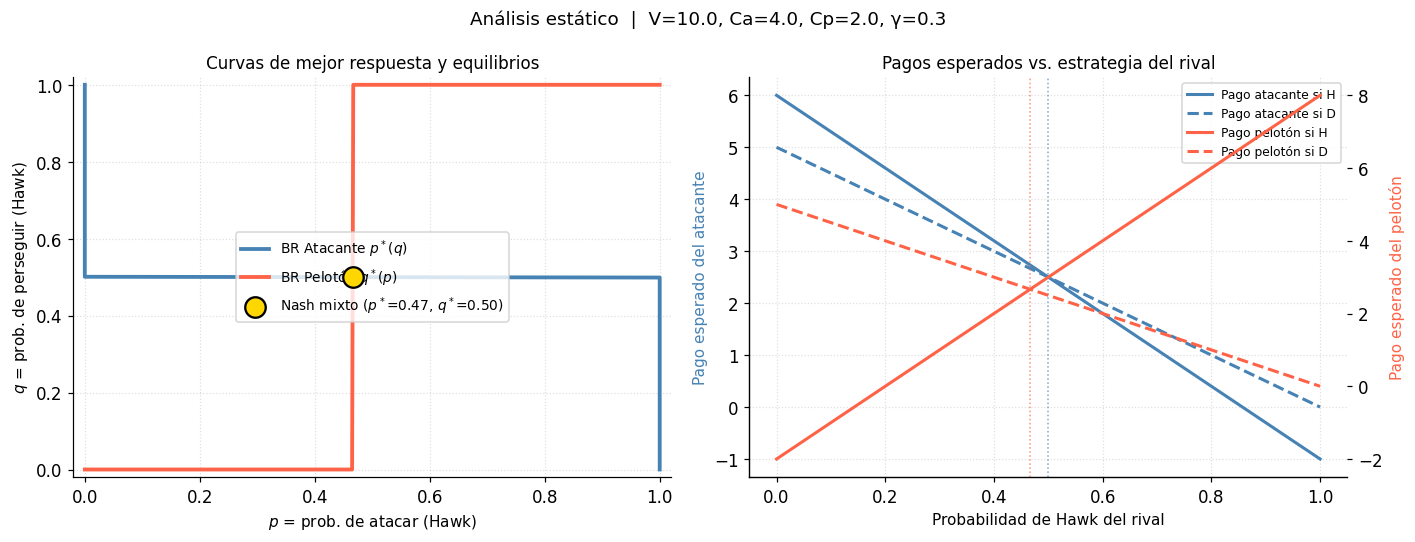

In [5]:
q_vals = np.linspace(0, 1, 500)
p_vals = np.linspace(0, 1, 500)

pago_aH = q_vals*A[0,0] + (1-q_vals)*A[0,1]
pago_aD = q_vals*A[1,0] + (1-q_vals)*A[1,1]
pago_pH = p_vals*B[0,0] + (1-p_vals)*B[1,0]
pago_pD = p_vals*B[0,1] + (1-p_vals)*B[1,1]

BR_atac_p  = np.where(pago_aH > pago_aD, 1.0, np.where(pago_aH < pago_aD, 0.0, p_star))
BR_pelot_q = np.where(pago_pH > pago_pD, 1.0, np.where(pago_pH < pago_pD, 0.0, q_star))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(BR_atac_p, q_vals, 'steelblue', lw=2.5, label='BR Atacante $p^*(q)$')
ax.plot(p_vals, BR_pelot_q, 'tomato', lw=2.5, label='BR Pelotón $q^*(p)$')
if valido:
    ax.scatter([p_star], [q_star], s=180, color='gold', edgecolors='black',
               lw=1.5, zorder=8,
               label=f'Nash mixto ($p^*$={p_star:.2f}, $q^*$={q_star:.2f})')
ax.set_xlabel('$p$ = prob. de atacar (Hawk)', fontsize=10)
ax.set_ylabel('$q$ = prob. de perseguir (Hawk)', fontsize=10)
ax.set_title('Curvas de mejor respuesta y equilibrios', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

ax2 = axes[1]
ax2.plot(q_vals, pago_aH, 'steelblue', lw=2, label='Pago atacante si H')
ax2.plot(q_vals, pago_aD, 'steelblue', lw=2, linestyle='--', label='Pago atacante si D')
ax2t = ax2.twinx()
ax2t.plot(p_vals, pago_pH, 'tomato', lw=2, label='Pago pelotón si H')
ax2t.plot(p_vals, pago_pD, 'tomato', lw=2, linestyle='--', label='Pago pelotón si D')
if valido:
    ax2.axvline(q_star, color='steelblue', lw=1, linestyle=':', alpha=0.7)
    ax2t.axvline(p_star, color='tomato', lw=1, linestyle=':', alpha=0.7)
ax2.set_xlabel('Probabilidad de Hawk del rival', fontsize=10)
ax2.set_ylabel('Pago esperado del atacante', color='steelblue', fontsize=10)
ax2t.set_ylabel('Pago esperado del pelotón', color='tomato', fontsize=10)
ax2.set_title('Pagos esperados vs. estrategia del rival', fontsize=11)
l1, lb1 = ax2.get_legend_handles_labels(); l2, lb2 = ax2t.get_legend_handles_labels()
ax2.legend(l1+l2, lb1+lb2, fontsize=8); ax2.grid(True, linestyle=':', alpha=0.4)

plt.suptitle(f'Análisis estático  |  V={V}, Ca={Ca}, Cp={Cp}, γ={gamma}', fontsize=12)
plt.tight_layout(); plt.show()

---
## Parte 4: Dinámicas poblacionales — fundamento teórico

Hasta aquí analizamos el juego como si fuera entre dos individuos fijos. La perspectiva de **dinámicas poblacionales** pregunta algo distinto: si hay una población grande de ciclistas que se enfrentan repetidamente y pueden cambiar de estrategia según los pagos que observan, ¿hacia dónde evoluciona la distribución de estrategias?

### 4.1 Notación y estado de la población

Consideremos una **población de atacantes** con masa total $m = 1$. El estado es:

$$x = [x_H, x_D]^\top \in \Delta = \{x \in \mathbb{R}^2_+ : x_H + x_D = 1\}$$

donde $x_H$ es la fracción de ciclistas que juegan Hawk (atacan) y $x_D$ los que juegan Dove.

La **función de fitness** para el juego Hawk-Dove simétrico (cuando dos ciclistas se encuentran aleatoriamente) es:

$$F_H(x) = x_H \cdot \frac{V - C}{2} + x_D \cdot V, \qquad F_D(x) = x_H \cdot 0 + x_D \cdot \frac{V}{2}$$

El **fitness promedio** es $\bar{F}(x) = x_H F_H + x_D F_D$.

El equilibrio poblacional satisface $F_H(x^*) = F_D(x^*)$, que da:

$$x_H^* = \frac{V}{C}$$

### 4.2 Proceso de revisión y mean dynamics

Cada agente recibe oportunidades de revisión según una distribución exponencial. En cada revisión, el agente compara su situación actual con la de otro agente elegido al azar y decide si cambia de estrategia según el **protocolo de revisión** $\rho_{ij}(F, x)$.

La ecuación diferencial que describe la evolución macroscópica es la **mean dynamics**:

$$\dot{x}_i = \sum_{j \in S} x_j \rho_{ji}(F(x), x) - x_i \sum_{j \in S} \rho_{ij}(F(x), x)$$

Diferentes protocolos dan lugar a diferentes dinámicas poblacionales conocidas.

In [6]:
# ── Parámetros del juego simétrico poblacional ────────────────────────────
# Para la versión poblacional usamos un juego simétrico donde dos ciclistas
# de la misma población se encuentran. C > V garantiza equilibrio interior.
V_pop = 6.0    # beneficio de una fuga exitosa (en la población)
C_pop = 10.0   # costo de atacar si el rival también ataca

xH_star_pop = V_pop / C_pop
print(f"Juego simétrico Hawk-Dove poblacional:")
print(f"  V = {V_pop},  C = {C_pop}")
print(f"  Equilibrio poblacional: x_H* = V/C = {xH_star_pop:.4f}")
print()

# Matriz del juego simétrico
# HH: (V-C)/2 cada uno
# HD: H obtiene V, D obtiene 0
# DD: V/2 cada uno
A_sym = np.array([
    [(V_pop - C_pop)/2,  V_pop],
    [0,                  V_pop/2],
])
print("Matriz de pago simétrica A (filas=estrategia propia, cols=estrategia rival):")
print(f"         Rival H      Rival D")
print(f"  Hawk   {A_sym[0,0]:>8.2f}   {A_sym[0,1]:>8.2f}")
print(f"  Dove   {A_sym[1,0]:>8.2f}   {A_sym[1,1]:>8.2f}")

Juego simétrico Hawk-Dove poblacional:
  V = 6.0,  C = 10.0
  Equilibrio poblacional: x_H* = V/C = 0.6000

Matriz de pago simétrica A (filas=estrategia propia, cols=estrategia rival):
         Rival H      Rival D
  Hawk      -2.00       6.00
  Dove       0.00       3.00


### 4.3 Protocolo de imitación proporcional por parejas → Replicador

$$\rho_{ij}(F, x) = x_j [F_j(x) - F_i(x)]_+$$

Un agente imita la estrategia del oponente con probabilidad proporcional a la diferencia de pagos. Sustituyendo en la mean dynamics se obtiene la **dinámica del replicador**:

$$\dot{x}_i = x_i \left( F_i(x) - \bar{F}(x) \right)$$

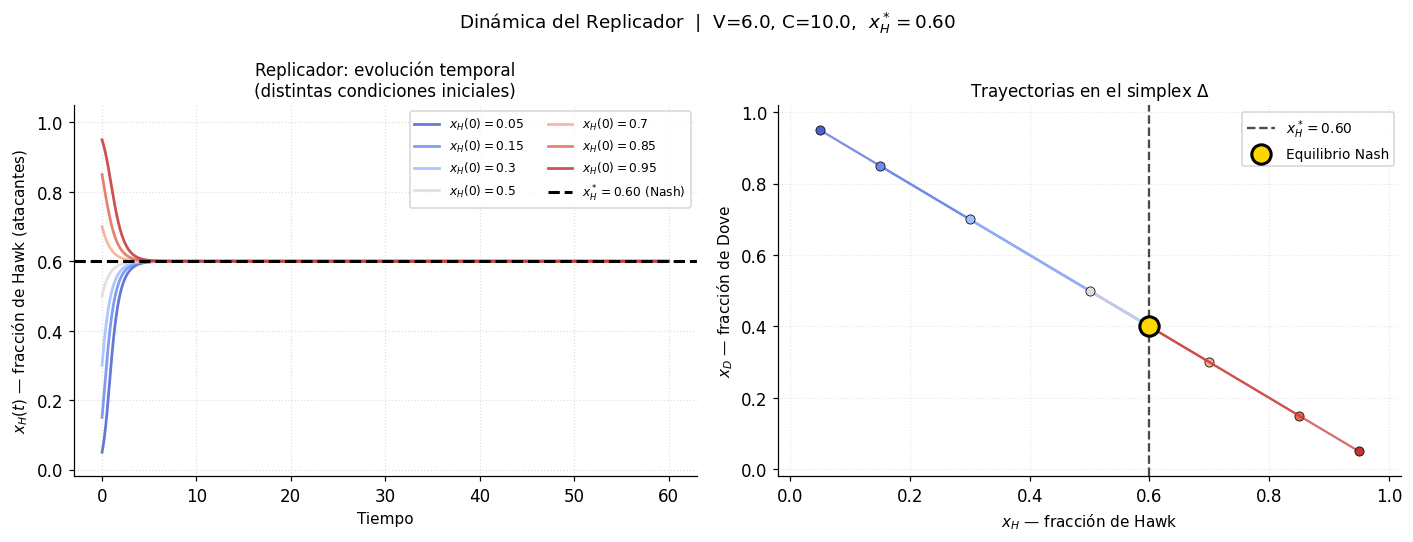

In [7]:
def fitness_sym(x, V, C):
    """Fitness para el juego Hawk-Dove simétrico. x = [xH, xD]."""
    F_H = x[0]*(V - C)/2 + x[1]*V
    F_D = x[1]*V/2
    return np.array([F_H, F_D])

def replicador(t, x, V, C):
    """Replicator dynamics: ẋ_i = x_i(F_i - F̄)."""
    x = np.clip(x, 1e-10, 1 - 1e-10)
    x = x / x.sum()
    F = fitness_sym(x, V, C)
    Fbar = x @ F
    return x * (F - Fbar)

t_span = (0, 60)
t_eval = np.linspace(*t_span, 800)
condiciones = [0.05, 0.15, 0.30, 0.50, 0.70, 0.85, 0.95]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = plt.cm.coolwarm

ax = axes[0]
for x0H in condiciones:
    sol = solve_ivp(replicador, t_span, [x0H, 1 - x0H], args=(V_pop, C_pop),
                    t_eval=t_eval, rtol=1e-10)
    color = cmap(x0H)
    ax.plot(sol.t, sol.y[0], color=color, lw=1.8, alpha=0.85,
            label=f'$x_H(0)={x0H}$')
ax.axhline(xH_star_pop, color='black', lw=2, linestyle='--',
           label=f'$x_H^*={xH_star_pop:.2f}$ (Nash)')
ax.set_xlabel('Tiempo', fontsize=10)
ax.set_ylabel('$x_H(t)$ — fracción de Hawk (atacantes)', fontsize=10)
ax.set_title('Replicador: evolución temporal\n(distintas condiciones iniciales)', fontsize=11)
ax.legend(fontsize=8, ncol=2); ax.grid(True, linestyle=':', alpha=0.4)
ax.set_ylim(-0.02, 1.05)

ax2 = axes[1]
xH_vals = np.linspace(0.001, 0.999, 400)
for x0H in condiciones:
    sol = solve_ivp(replicador, t_span, [x0H, 1 - x0H], args=(V_pop, C_pop),
                    t_eval=t_eval, rtol=1e-10)
    xH_traj = sol.y[0]
    xD_traj = sol.y[1]
    color = cmap(x0H)
    ax2.plot(xH_traj, xD_traj, color=color, lw=1.5, alpha=0.7)
    ax2.plot(x0H, 1 - x0H, 'o', color=color, ms=6,
             markeredgecolor='black', markeredgewidth=0.5)

ax2.axvline(xH_star_pop, color='black', lw=1.5, linestyle='--', alpha=0.7,
            label=f'$x_H^*={xH_star_pop:.2f}$')
ax2.scatter([xH_star_pop], [1 - xH_star_pop], s=160, color='gold',
            edgecolors='black', lw=2, zorder=9, label='Equilibrio Nash')
ax2.set_xlabel('$x_H$ — fracción de Hawk', fontsize=10)
ax2.set_ylabel('$x_D$ — fracción de Dove', fontsize=10)
ax2.set_title('Trayectorias en el simplex $\Delta$', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, linestyle=':', alpha=0.3)
ax2.set_xlim(-0.02, 1.02); ax2.set_ylim(-0.02, 1.02)

plt.suptitle(f'Dinámica del Replicador  |  V={V_pop}, C={C_pop},  $x_H^*={xH_star_pop:.2f}$',
             fontsize=12)
plt.tight_layout(); plt.show()

### 4.4 Protocolo de comparación por parejas → Smith dynamics

$$\rho_{ij}(F, x) = [F_j(x) - F_i(x)]_+$$

El agente cambia si el rival tiene mejor pago, con tasa proporcional al exceso. La mean dynamics resultante es la **dinámica de Smith**:

$$\dot{x}_i = \sum_{j \in S} x_j [F_i(x) - F_j(x)]_+ - x_i \sum_{j \in S} [F_j(x) - F_i(x)]_+$$

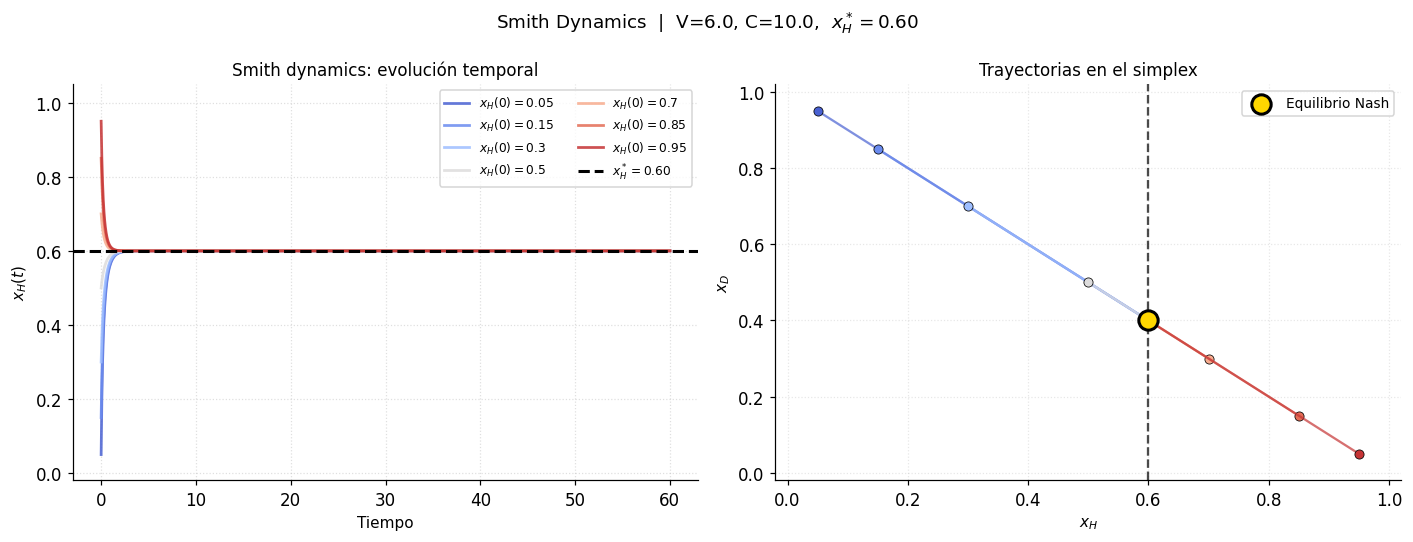

In [8]:
def smith(t, x, V, C):
    """Smith dynamics: protocolo de comparación por parejas."""
    x = np.clip(x, 0, 1)
    x = x / x.sum()
    F = fitness_sym(x, V, C)
    n = len(x)
    dxdt = np.zeros(n)
    for i in range(n):
        dxdt[i] = (sum(x[j] * max(0, F[i] - F[j]) for j in range(n))
                   - x[i] * sum(max(0, F[j] - F[i]) for j in range(n)))
    return dxdt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for x0H in condiciones:
    sol = solve_ivp(smith, t_span, [x0H, 1 - x0H], args=(V_pop, C_pop),
                    t_eval=t_eval, rtol=1e-9)
    ax.plot(sol.t, sol.y[0], color=cmap(x0H), lw=1.8, alpha=0.85,
            label=f'$x_H(0)={x0H}$')
ax.axhline(xH_star_pop, color='black', lw=2, linestyle='--',
           label=f'$x_H^*={xH_star_pop:.2f}$')
ax.set_xlabel('Tiempo', fontsize=10)
ax.set_ylabel('$x_H(t)$', fontsize=10)
ax.set_title('Smith dynamics: evolución temporal', fontsize=11)
ax.legend(fontsize=8, ncol=2); ax.grid(True, linestyle=':', alpha=0.4)
ax.set_ylim(-0.02, 1.05)

ax2 = axes[1]
for x0H in condiciones:
    sol = solve_ivp(smith, t_span, [x0H, 1 - x0H], args=(V_pop, C_pop),
                    t_eval=t_eval, rtol=1e-9)
    ax2.plot(sol.y[0], sol.y[1], color=cmap(x0H), lw=1.5, alpha=0.7)
    ax2.plot(x0H, 1 - x0H, 'o', color=cmap(x0H), ms=6,
             markeredgecolor='black', markeredgewidth=0.5)
ax2.scatter([xH_star_pop], [1 - xH_star_pop], s=160, color='gold',
            edgecolors='black', lw=2, zorder=9, label='Equilibrio Nash')
ax2.axvline(xH_star_pop, color='black', lw=1.5, linestyle='--', alpha=0.7)
ax2.set_xlabel('$x_H$', fontsize=10); ax2.set_ylabel('$x_D$', fontsize=10)
ax2.set_title('Trayectorias en el simplex', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, linestyle=':', alpha=0.3)
ax2.set_xlim(-0.02, 1.02); ax2.set_ylim(-0.02, 1.02)

plt.suptitle(f'Smith Dynamics  |  V={V_pop}, C={C_pop},  $x_H^*={xH_star_pop:.2f}$', fontsize=12)
plt.tight_layout(); plt.show()

### 4.5 Protocolo de escogencia Logit → Logit dynamics

$$\rho_{ij}(F, x) = \sigma_j(F) = \frac{\exp(\eta^{-1} F_j(x))}{\sum_k \exp(\eta^{-1} F_k(x))}$$

Con $\eta > 0$ como nivel de ruido. Para $\eta \to 0$ el agente siempre copia la estrategia más rentable (racional); para $\eta \to \infty$ la elección es casi aleatoria. Usando las **exact target dynamics** se obtiene la **dinámica de Logit**:

$$\dot{x}_i = \frac{\exp(\eta^{-1} F_i(x))}{\sum_k \exp(\eta^{-1} F_k(x))} - x_i$$

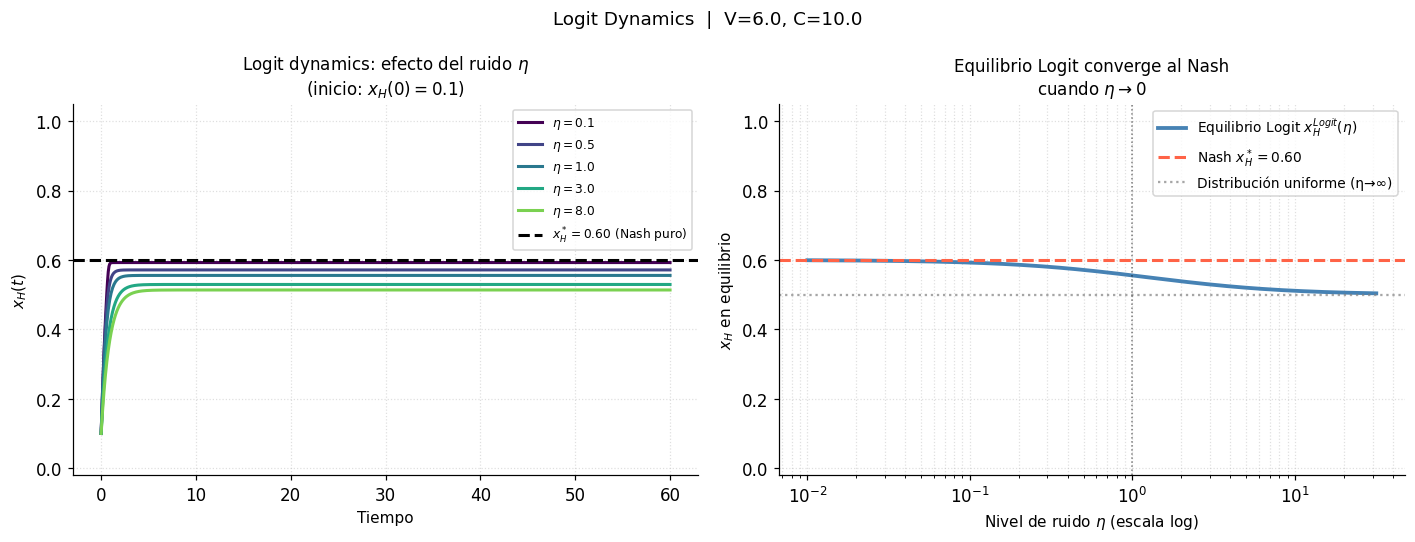

In [9]:
def logit(t, x, V, C, eta=1.0):
    """Logit choice dynamics: exact target dynamics con protocolo logit."""
    x = np.clip(x, 1e-10, 1 - 1e-10)
    x = x / x.sum()
    F = fitness_sym(x, V, C)
    # Estabilidad numérica: restar el máximo
    F_shift = F - F.max()
    sigma = np.exp(F_shift / eta)
    sigma /= sigma.sum()
    return sigma - x

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: efecto del nivel de ruido η
ax = axes[0]
etas = [0.1, 0.5, 1.0, 3.0, 8.0]
cmap_eta = plt.cm.viridis
x0_fixed = [0.1, 0.9]

for k, eta_k in enumerate(etas):
    sol = solve_ivp(logit, t_span, x0_fixed, args=(V_pop, C_pop, eta_k),
                    t_eval=t_eval, rtol=1e-9)
    ax.plot(sol.t, sol.y[0], color=cmap_eta(k/len(etas)), lw=2,
            label=f'$\\eta={eta_k}$')
ax.axhline(xH_star_pop, color='black', lw=2, linestyle='--',
           label=f'$x_H^*={xH_star_pop:.2f}$ (Nash puro)')
ax.set_xlabel('Tiempo', fontsize=10)
ax.set_ylabel('$x_H(t)$', fontsize=10)
ax.set_title('Logit dynamics: efecto del ruido $\\eta$\n'
             f'(inicio: $x_H(0)={x0_fixed[0]}$)', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, linestyle=':', alpha=0.4)
ax.set_ylim(-0.02, 1.05)

# Panel derecho: equilibrio Logit vs Nash en función de η
ax2 = axes[1]
eta_range = np.logspace(-2, 1.5, 200)
xH_logit_eq = []
for eta_k in eta_range:
    sol_k = solve_ivp(logit, (0, 200), [0.5, 0.5], args=(V_pop, C_pop, eta_k),
                      t_eval=[200], rtol=1e-9)
    xH_logit_eq.append(sol_k.y[0, -1])

ax2.semilogx(eta_range, xH_logit_eq, 'steelblue', lw=2.5,
             label='Equilibrio Logit $x_H^{Logit}(\\eta)$')
ax2.axhline(xH_star_pop, color='tomato', lw=2, linestyle='--',
            label=f'Nash $x_H^*={xH_star_pop:.2f}$')
ax2.axhline(0.5, color='gray', lw=1.5, linestyle=':', alpha=0.7,
            label='Distribución uniforme (η→∞)')
ax2.axvline(1.0, color='black', lw=1, linestyle=':', alpha=0.5)
ax2.set_xlabel('Nivel de ruido $\\eta$ (escala log)', fontsize=10)
ax2.set_ylabel('$x_H$ en equilibrio', fontsize=10)
ax2.set_title('Equilibrio Logit converge al Nash\ncuando $\\eta \\to 0$', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, which='both', linestyle=':', alpha=0.4)
ax2.set_ylim(-0.02, 1.05)

plt.suptitle(f'Logit Dynamics  |  V={V_pop}, C={C_pop}', fontsize=12)
plt.tight_layout(); plt.show()

---
## Parte 5: Comparación de dinámicas poblacionales

Las tres dinámicas (Replicador, Smith, Logit) tienen el mismo equilibrio interior $x_H^* = V/C$ como punto fijo, pero difieren en la **velocidad de convergencia** y en la **trayectoria**.

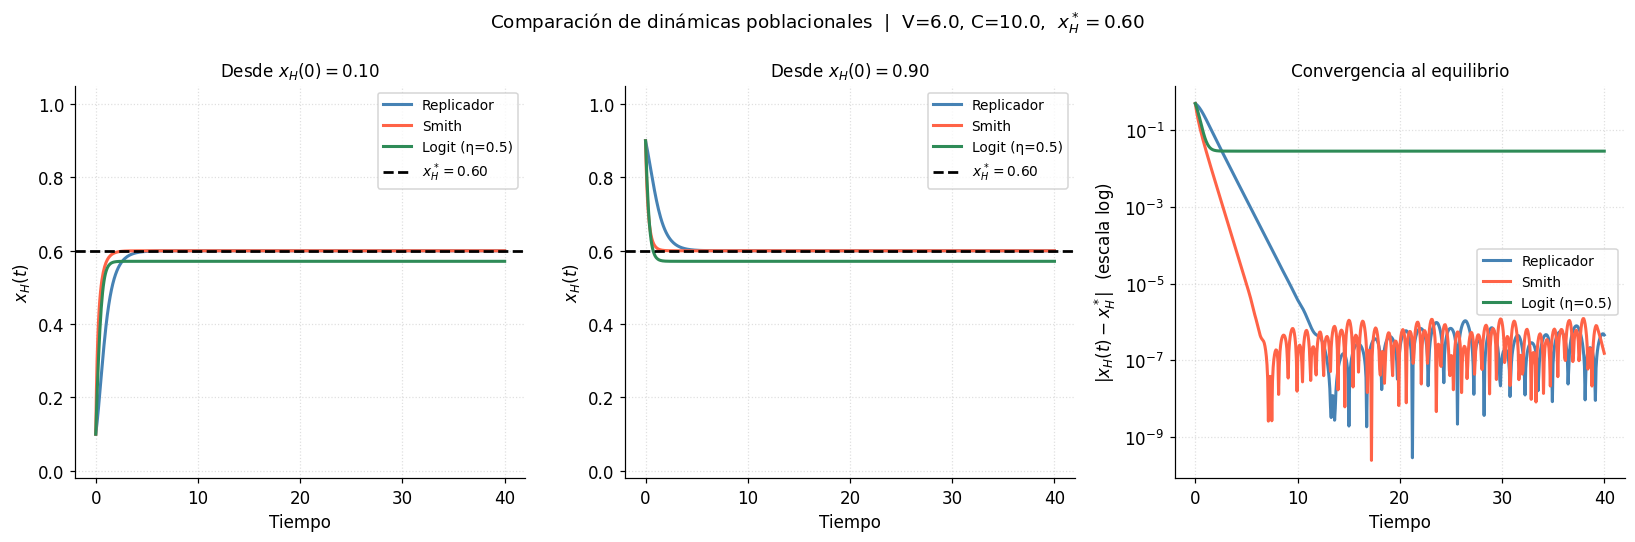

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
t_span_c = (0, 40)
t_eval_c = np.linspace(*t_span_c, 600)

nombres = ['Replicador', 'Smith', 'Logit (η=0.5)']
colores_din = ['steelblue', 'tomato', 'seagreen']
funciones  = [
    lambda t, x: replicador(t, x, V_pop, C_pop),
    lambda t, x: smith(t, x, V_pop, C_pop),
    lambda t, x: logit(t, x, V_pop, C_pop, eta=0.5),
]

# Panel 1: evolución temporal desde x_H(0) = 0.1
ax = axes[0]
for fn, nombre, color in zip(funciones, nombres, colores_din):
    sol = solve_ivp(fn, t_span_c, [0.1, 0.9], t_eval=t_eval_c, rtol=1e-9)
    ax.plot(sol.t, sol.y[0], color=color, lw=2, label=nombre)
ax.axhline(xH_star_pop, color='black', lw=1.8, linestyle='--',
           label=f'$x_H^*={xH_star_pop:.2f}$')
ax.set_xlabel('Tiempo'); ax.set_ylabel('$x_H(t)$')
ax.set_title('Desde $x_H(0) = 0.10$', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.4); ax.set_ylim(-0.02, 1.05)

# Panel 2: evolución temporal desde x_H(0) = 0.9
ax2 = axes[1]
for fn, nombre, color in zip(funciones, nombres, colores_din):
    sol = solve_ivp(fn, t_span_c, [0.9, 0.1], t_eval=t_eval_c, rtol=1e-9)
    ax2.plot(sol.t, sol.y[0], color=color, lw=2, label=nombre)
ax2.axhline(xH_star_pop, color='black', lw=1.8, linestyle='--',
            label=f'$x_H^*={xH_star_pop:.2f}$')
ax2.set_xlabel('Tiempo'); ax2.set_ylabel('$x_H(t)$')
ax2.set_title('Desde $x_H(0) = 0.90$', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(True, linestyle=':', alpha=0.4); ax2.set_ylim(-0.02, 1.05)

# Panel 3: error al equilibrio en escala log
ax3 = axes[2]
for fn, nombre, color in zip(funciones, nombres, colores_din):
    sol = solve_ivp(fn, t_span_c, [0.1, 0.9], t_eval=t_eval_c, rtol=1e-9)
    error = np.abs(sol.y[0] - xH_star_pop) + 1e-12
    ax3.semilogy(sol.t, error, color=color, lw=2, label=nombre)
ax3.set_xlabel('Tiempo'); ax3.set_ylabel('$|x_H(t) - x_H^*|$  (escala log)')
ax3.set_title('Convergencia al equilibrio', fontsize=11)
ax3.legend(fontsize=9); ax3.grid(True, which='both', linestyle=':', alpha=0.4)

plt.suptitle(f'Comparación de dinámicas poblacionales  |  V={V_pop}, C={C_pop},  $x_H^*={xH_star_pop:.2f}$',
             fontsize=12)
plt.tight_layout(); plt.show()

---
## Parte 6: Replicador 2D — juego asimétrico (atacante vs. pelotón)

Extendemos la perspectiva poblacional al juego asimétrico. Ahora hay **dos poblaciones** que coevolucionan: la de atacantes y la del pelotón. Cada una tiene su propia dinámica del replicador:

$$\dot{p} = p(1-p)\left[f_H^A(q) - f_D^A(q)\right]$$
$$\dot{q} = q(1-q)\left[f_H^P(p) - f_D^P(p)\right]$$

donde $p$ es la fracción de atacantes que eligen Hawk y $q$ la fracción del pelotón que elige Hawk.

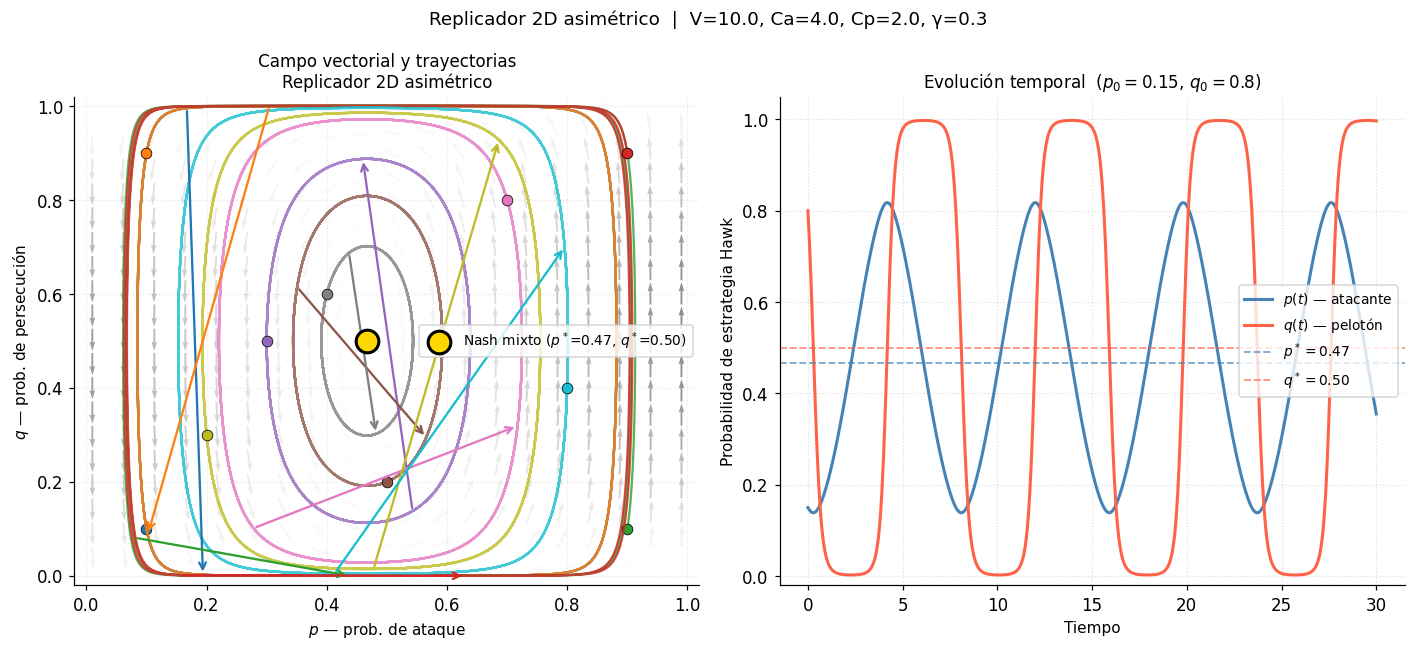

In [11]:
def replicador_2D(t, y, A, B):
    """Replicador asimétrico de dos poblaciones."""
    p, q = np.clip(y, 1e-10, 1 - 1e-10)
    fH_A = q*A[0,0] + (1-q)*A[0,1]
    fD_A = q*A[1,0] + (1-q)*A[1,1]
    fH_P = p*B[0,0] + (1-p)*B[1,0]
    fD_P = p*B[0,1] + (1-p)*B[1,1]
    return [p*(1-p)*(fH_A - fD_A), q*(1-q)*(fH_P - fD_P)]

# Campo vectorial
res = 20
p_grid = np.linspace(0.01, 0.99, res)
q_grid = np.linspace(0.01, 0.99, res)
PP, QQ = np.meshgrid(p_grid, q_grid)
DP, DQ = np.zeros_like(PP), np.zeros_like(QQ)
for i in range(res):
    for j in range(res):
        dy = replicador_2D(0, [PP[i,j], QQ[i,j]], A, B)
        DP[i,j], DQ[i,j] = dy
mag = np.sqrt(DP**2 + DQ**2) + 1e-10

t_span2D = (0, 30)
t_eval2D = np.linspace(*t_span2D, 800)
cis_2D = [[0.1,0.1],[0.1,0.9],[0.9,0.1],[0.9,0.9],
          [0.3,0.5],[0.5,0.2],[0.7,0.8],[0.4,0.6],[0.2,0.3],[0.8,0.4]]
cmap_traj = plt.cm.tab10

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.quiver(PP, QQ, DP/mag, DQ/mag, mag, cmap='Greys', alpha=0.45, scale=28, width=0.003)
for k, y0 in enumerate(cis_2D):
    sol = solve_ivp(replicador_2D, t_span2D, y0, args=(A, B),
                    t_eval=t_eval2D, rtol=1e-9)
    c = cmap_traj(k/len(cis_2D))
    ax.plot(sol.y[0], sol.y[1], color=c, lw=1.5, alpha=0.8)
    ax.plot(y0[0], y0[1], 'o', color=c, ms=7,
            markeredgecolor='black', markeredgewidth=0.5)
    ax.annotate('', xy=(sol.y[0,-1], sol.y[1,-1]),
                xytext=(sol.y[0,-60], sol.y[1,-60]),
                arrowprops=dict(arrowstyle='->', color=c, lw=1.5))
if valido:
    ax.scatter([p_star], [q_star], s=220, color='gold', edgecolors='black',
               lw=2, zorder=9, label=f'Nash mixto ($p^*$={p_star:.2f}, $q^*$={q_star:.2f})')
ax.set_xlabel('$p$ — prob. de ataque', fontsize=10)
ax.set_ylabel('$q$ — prob. de persecución', fontsize=10)
ax.set_title('Campo vectorial y trayectorias\nReplicador 2D asimétrico', fontsize=11)
ax.legend(fontsize=9); ax.grid(True, linestyle=':', alpha=0.3)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

ax2 = axes[1]
y0_ej = [0.15, 0.80]
sol_ej = solve_ivp(replicador_2D, t_span2D, y0_ej, args=(A, B),
                   t_eval=t_eval2D, rtol=1e-9)
ax2.plot(sol_ej.t, sol_ej.y[0], 'steelblue', lw=2, label='$p(t)$ — atacante')
ax2.plot(sol_ej.t, sol_ej.y[1], 'tomato',    lw=2, label='$q(t)$ — pelotón')
if valido:
    ax2.axhline(p_star, color='steelblue', lw=1.2, linestyle='--', alpha=0.7,
                label=f'$p^*={p_star:.2f}$')
    ax2.axhline(q_star, color='tomato',    lw=1.2, linestyle='--', alpha=0.7,
                label=f'$q^*={q_star:.2f}$')
ax2.set_xlabel('Tiempo', fontsize=10)
ax2.set_ylabel('Probabilidad de estrategia Hawk', fontsize=10)
ax2.set_title(f'Evolución temporal  ($p_0={y0_ej[0]}$, $q_0={y0_ej[1]}$)', fontsize=11)
ax2.legend(fontsize=9); ax2.set_ylim(-0.02, 1.05)
ax2.grid(True, linestyle=':', alpha=0.4)

plt.suptitle(f'Replicador 2D asimétrico  |  V={V}, Ca={Ca}, Cp={Cp}, γ={gamma}', fontsize=12)
plt.tight_layout(); plt.show()

---
## Parte 7: Análisis de estabilidad — Jacobiano en los puntos fijos

Los puntos fijos del sistema 2D son los $(p, q)$ donde $\dot{p} = \dot{q} = 0$: las cuatro esquinas y el equilibrio mixto interior. La estabilidad se determina por los eigenvalores del Jacobiano:

$$J = \begin{pmatrix} \partial \dot{p}/\partial p & \partial \dot{p}/\partial q \\ \partial \dot{q}/\partial p & \partial \dot{q}/\partial q \end{pmatrix}$$

- Eigenvalores con parte real **negativa** → atractor estable.
- Algún eigenvalor con parte real **positiva** → silla o repulsor.
- Puramente imaginarios → centro (trayectorias periódicas).

In [15]:
def jacobiano(p0, q0, A, B, dx=1e-6):
    def F(y): return np.array(replicador_2D(0, y, A, B))
    f0 = F([p0, q0]); J = np.zeros((2, 2))
    for k in range(2):
        y_plus = [p0, q0]; y_plus[k] += dx
        J[:, k] = (F(y_plus) - f0) / dx
    return J

def clasificar(eigs):
    re = eigs.real
    if np.all(re < -1e-7): return "Estable (atractor)"
    if np.all(re >  1e-7): return "Inestable (repulsor)"
    if np.any(re >  1e-7) and np.any(re < -1e-7): return "Silla de montar"
    if np.all(np.abs(re) < 1e-7): return "Centro"
    return "Indeterminado"

eps = 1e-4
puntos = [
    (eps,     eps,     "(0,0) Dove/Dove"),
    (eps,     1-eps,   "(0,1) Dove/Hawk"),
    (1-eps,   eps,     "(1,0) Hawk/Dove"),
    (1-eps,   1-eps,   "(1,1) Hawk/Hawk"),
]
if valido:
    puntos.append((p_star, q_star, f"($p^*$={p_star:.3f}, $q^*$={q_star:.3f}) Mixto"))


print("ANÁLISIS DE ESTABILIDAD — EIGENVALORES DEL JACOBIANO")

resultados = []
for p0, q0, nombre in puntos:
    J = jacobiano(p0, q0, A, B)
    eigs = eigvals(J)
    cl = clasificar(eigs)
    resultados.append((p0, q0, nombre, eigs, cl))
    print(f"Punto: {nombre}")
    print(f"  λ₁ = {eigs[0]:.4f},  λ₂ = {eigs[1]:.4f}  →  {cl}")
    print()

ANÁLISIS DE ESTABILIDAD — EIGENVALORES DEL JACOBIANO
Punto: (0,0) Dove/Dove
  λ₁ = 0.9996,  λ₂ = -6.9971  →  Silla de montar

Punto: (0,1) Dove/Hawk
  λ₁ = -0.9996,  λ₂ = 6.9971  →  Silla de montar

Punto: (1,0) Hawk/Dove
  λ₁ = -0.9996,  λ₂ = 7.9969  →  Silla de montar

Punto: (1,1) Hawk/Hawk
  λ₁ = 0.9996,  λ₂ = -7.9969  →  Silla de montar

Punto: ($p^*$=0.467, $q^*$=0.500) Mixto
  λ₁ = -0.0000+1.3663j,  λ₂ = -0.0000-1.3663j  →  Centro



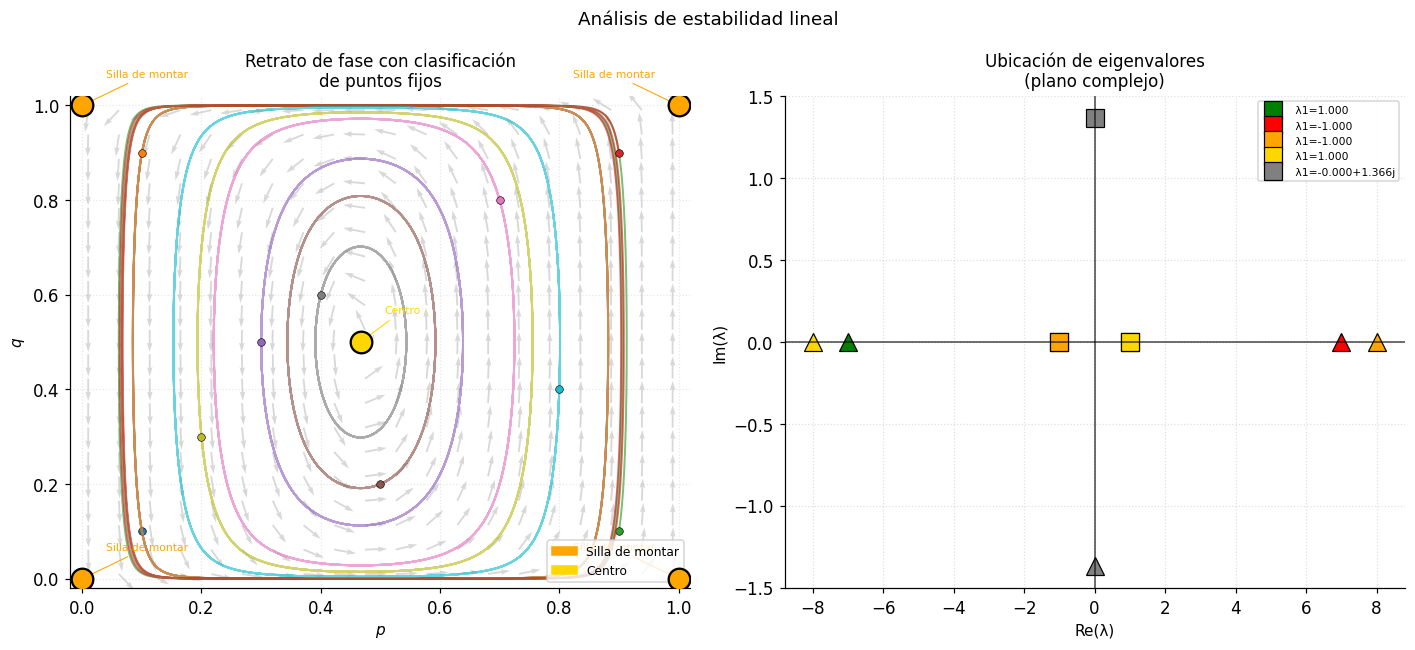

In [13]:
colores_cl = {
    "Estable (atractor)":   "green",
    "Inestable (repulsor)": "red",
    "Silla de montar":      "orange",
    "Centro":               "gold",
    "Indeterminado":        "gray",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

ax = axes[0]
ax.quiver(PP, QQ, DP/mag, DQ/mag, alpha=0.30, color='gray', scale=28, width=0.003)
for k, y0 in enumerate(cis_2D):
    sol = solve_ivp(replicador_2D, t_span2D, y0, args=(A, B),
                    t_eval=t_eval2D, rtol=1e-9)
    ax.plot(sol.y[0], sol.y[1], lw=1.3, alpha=0.65,
            color=cmap_traj(k/len(cis_2D)))
    ax.plot(y0[0], y0[1], 'o', ms=5, color=cmap_traj(k/len(cis_2D)),
            markeredgecolor='black', markeredgewidth=0.4)

for p0, q0, nombre, eigs, cl in resultados:
    color_pt = colores_cl.get(cl, 'gray')
    ax.scatter([p0], [q0], s=200, color=color_pt, edgecolors='black',
               lw=1.5, zorder=9)
    ox = 0.04 if p0 < 0.5 else -0.04
    ax.annotate(cl, xy=(p0, q0), xytext=(p0+ox, q0+0.06),
                fontsize=7, ha='left' if p0 < 0.5 else 'right', color=color_pt,
                arrowprops=dict(arrowstyle='-', color=color_pt, lw=0.7))

patches = [mpatches.Patch(color=c, label=k) for k, c in colores_cl.items()
           if k in [r[4] for r in resultados]]
ax.legend(handles=patches, fontsize=8, loc='lower right')
ax.set_xlabel('$p$', fontsize=10); ax.set_ylabel('$q$', fontsize=10)
ax.set_title('Retrato de fase con clasificación\nde puntos fijos', fontsize=11)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(True, linestyle=':', alpha=0.3)

ax2 = axes[1]
eig_data = [(r[2].split('(')[0].strip(), r[3]) for r in resultados]
xs = np.linspace(-1.2, 1.2, 300)
for k, (nombre_pt, eigs) in enumerate(eig_data):
    color_k = list(colores_cl.values())[k % len(colores_cl)]
    for j, lam in enumerate(eigs):
        ax2.plot(lam.real, lam.imag, 's' if j == 0 else '^',
                 color=color_k, ms=12, markeredgecolor='black', markeredgewidth=0.8,
                 label=f'{nombre_pt} λ{j+1}={lam:.3f}' if j == 0 else '')

ax2.axvline(0, color='black', lw=1.2, linestyle='-', alpha=0.6)
ax2.axhline(0, color='black', lw=1.2, linestyle='-', alpha=0.6)
ax2.set_xlabel('Re(λ)', fontsize=10); ax2.set_ylabel('Im(λ)', fontsize=10)
ax2.set_title('Ubicación de eigenvalores\n(plano complejo)', fontsize=11)
ax2.legend(fontsize=7, ncol=1); ax2.grid(True, linestyle=':', alpha=0.4)

plt.suptitle('Análisis de estabilidad lineal', fontsize=12)
plt.tight_layout(); plt.show()

---
## Parte 8: Análisis de sensibilidad del equilibrio mixto

¿Cómo cambia $(p^*, q^*)$ cuando varían los parámetros? Esto responde preguntas ciclísticas concretas: ¿qué pasa al final de una etapa larga cuando el atacante está más cansado? ¿Qué pasa cuando el pelotón es muy numeroso y perseguir es barato?

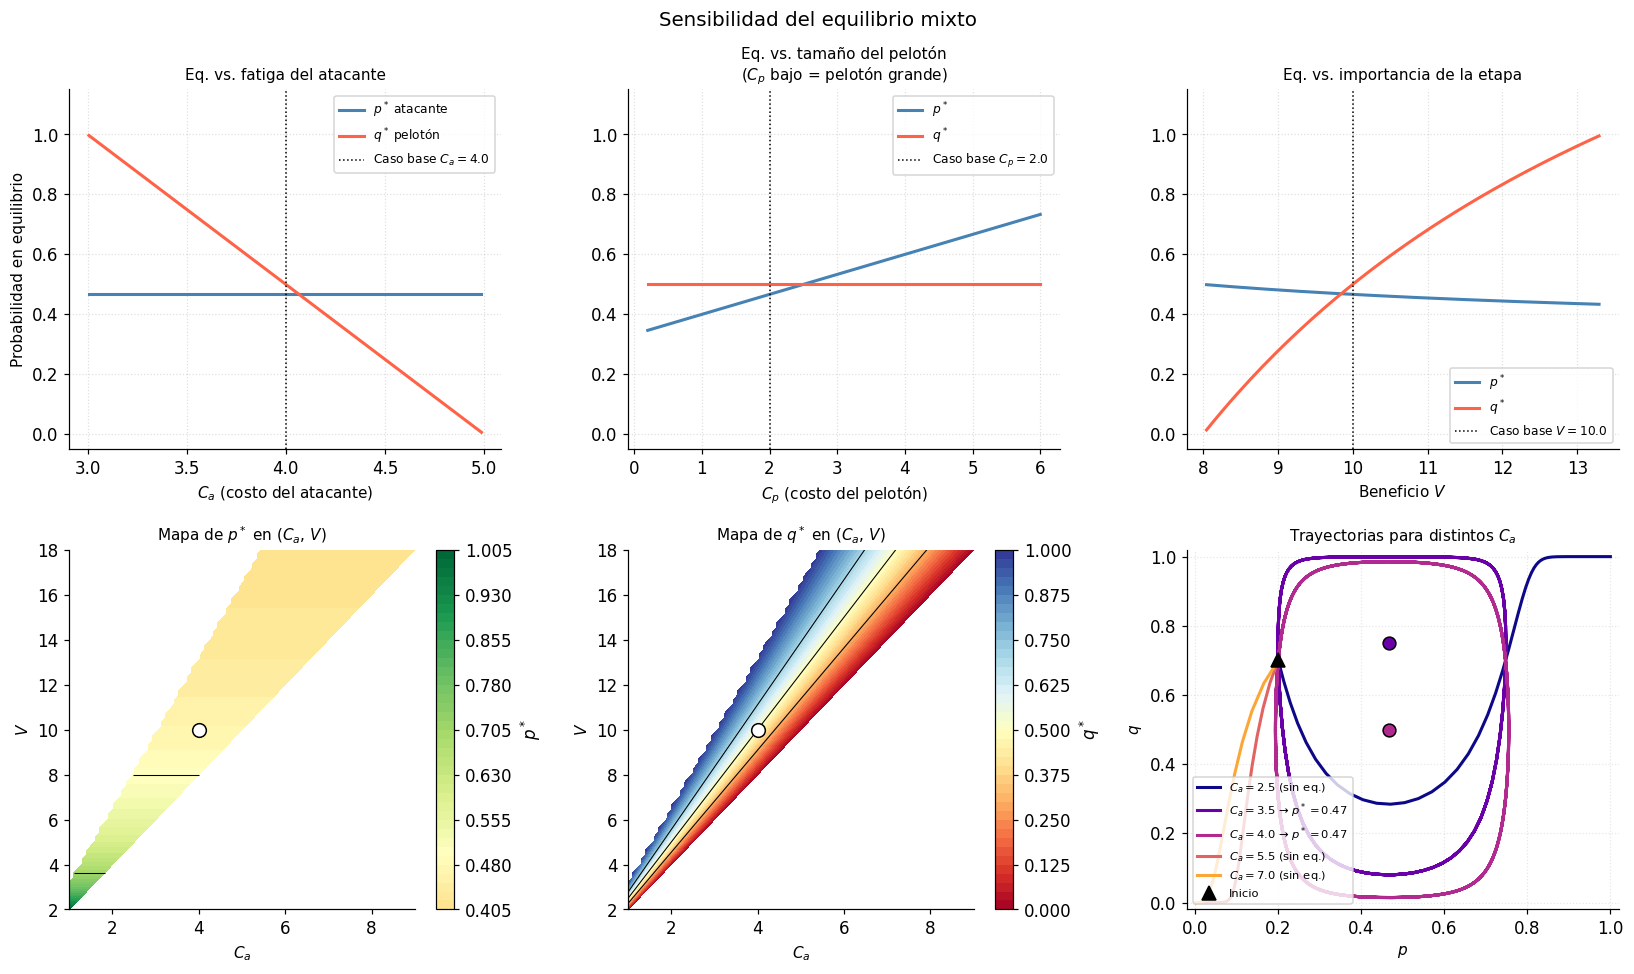

Interpretación de resultados:
  Ca alto (fatiga): el atacante ataca menos (p* cae).
  Cp bajo (pelotón grande): perseguir es barato → q* sube → p* cae.
  V alto (etapa importante): ambos intensifican el comportamiento.


In [14]:
def eq_mixto(V, Ca, Cp, gamma):
    A_l = np.array([[gamma*V - Ca, V - Ca], [0, V/2]])
    B_l = np.array([[V - Cp, 0], [-Cp, V/2]])
    nq = A_l[1,1]-A_l[0,1]; dq = A_l[0,0]-A_l[1,0]-A_l[0,1]+A_l[1,1]
    np_ = B_l[1,1]-B_l[1,0]; dp = B_l[0,0]-B_l[0,1]-B_l[1,0]+B_l[1,1]
    if abs(dq) < 1e-10 or abs(dp) < 1e-10: return np.nan, np.nan
    qs = nq/dq; ps = np_/dp
    return (ps, qs) if (0 <= ps <= 1 and 0 <= qs <= 1) else (np.nan, np.nan)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

Ca_r = np.linspace(1, 9, 300)
p_Ca = [eq_mixto(V, ca, Cp, gamma)[0] for ca in Ca_r]
q_Ca = [eq_mixto(V, ca, Cp, gamma)[1] for ca in Ca_r]
axes[0,0].plot(Ca_r, p_Ca, 'steelblue', lw=2, label='$p^*$ atacante')
axes[0,0].plot(Ca_r, q_Ca, 'tomato',    lw=2, label='$q^*$ pelotón')
axes[0,0].axvline(Ca, color='black', lw=1, linestyle=':', label=f'Caso base $C_a={Ca}$')
axes[0,0].set_xlabel('$C_a$ (costo del atacante)', fontsize=10)
axes[0,0].set_ylabel('Probabilidad en equilibrio', fontsize=10)
axes[0,0].set_title('Eq. vs. fatiga del atacante', fontsize=10)
axes[0,0].legend(fontsize=8); axes[0,0].set_ylim(-0.05, 1.15)
axes[0,0].grid(True, linestyle=':', alpha=0.4)

Cp_r = np.linspace(0.2, 6, 300)
p_Cp = [eq_mixto(V, Ca, cp, gamma)[0] for cp in Cp_r]
q_Cp = [eq_mixto(V, Ca, cp, gamma)[1] for cp in Cp_r]
axes[0,1].plot(Cp_r, p_Cp, 'steelblue', lw=2, label='$p^*$')
axes[0,1].plot(Cp_r, q_Cp, 'tomato',    lw=2, label='$q^*$')
axes[0,1].axvline(Cp, color='black', lw=1, linestyle=':', label=f'Caso base $C_p={Cp}$')
axes[0,1].set_xlabel('$C_p$ (costo del pelotón)', fontsize=10)
axes[0,1].set_title('Eq. vs. tamaño del pelotón\n($C_p$ bajo = pelotón grande)', fontsize=10)
axes[0,1].legend(fontsize=8); axes[0,1].set_ylim(-0.05, 1.15)
axes[0,1].grid(True, linestyle=':', alpha=0.4)

V_r = np.linspace(2, 18, 300)
p_V = [eq_mixto(v, Ca, Cp, gamma)[0] for v in V_r]
q_V = [eq_mixto(v, Ca, Cp, gamma)[1] for v in V_r]
axes[0,2].plot(V_r, p_V, 'steelblue', lw=2, label='$p^*$')
axes[0,2].plot(V_r, q_V, 'tomato',    lw=2, label='$q^*$')
axes[0,2].axvline(V, color='black', lw=1, linestyle=':', label=f'Caso base $V={V}$')
axes[0,2].set_xlabel('Beneficio $V$', fontsize=10)
axes[0,2].set_title('Eq. vs. importancia de la etapa', fontsize=10)
axes[0,2].legend(fontsize=8); axes[0,2].set_ylim(-0.05, 1.15)
axes[0,2].grid(True, linestyle=':', alpha=0.4)

Ca_g = np.linspace(1, 9, 80); V_g = np.linspace(2, 18, 80)
CaG, VG = np.meshgrid(Ca_g, V_g)
P_map = np.full_like(CaG, np.nan); Q_map = np.full_like(CaG, np.nan)
for i in range(CaG.shape[0]):
    for j in range(CaG.shape[1]):
        P_map[i,j], Q_map[i,j] = eq_mixto(VG[i,j], CaG[i,j], Cp, gamma)

im1 = axes[1,0].contourf(Ca_g, V_g, P_map, levels=40, cmap='RdYlGn', vmin=0, vmax=1)
axes[1,0].contour(Ca_g, V_g, P_map, levels=[0.3,0.5,0.7], colors='black', linewidths=0.7)
axes[1,0].scatter([Ca], [V], color='white', edgecolors='black', s=80, zorder=5)
plt.colorbar(im1, ax=axes[1,0], label='$p^*$')
axes[1,0].set_xlabel('$C_a$', fontsize=10); axes[1,0].set_ylabel('$V$', fontsize=10)
axes[1,0].set_title('Mapa de $p^*$ en ($C_a$, $V$)', fontsize=10)

im2 = axes[1,1].contourf(Ca_g, V_g, Q_map, levels=40, cmap='RdYlBu', vmin=0, vmax=1)
axes[1,1].contour(Ca_g, V_g, Q_map, levels=[0.3,0.5,0.7], colors='black', linewidths=0.7)
axes[1,1].scatter([Ca], [V], color='white', edgecolors='black', s=80, zorder=5)
plt.colorbar(im2, ax=axes[1,1], label='$q^*$')
axes[1,1].set_xlabel('$C_a$', fontsize=10); axes[1,1].set_ylabel('$V$', fontsize=10)
axes[1,1].set_title('Mapa de $q^*$ en ($C_a$, $V$)', fontsize=10)

Ca_esc = [2.5, 3.5, 4.0, 5.5, 7.0]
cmap_esc = plt.cm.plasma
y0_f = [0.2, 0.7]
for k, ca_k in enumerate(Ca_esc):
    A_k = np.array([[gamma*V - ca_k, V - ca_k], [0, V/2]])
    sol_k = solve_ivp(replicador_2D, (0, 35), y0_f, args=(A_k, B),
                      t_eval=np.linspace(0, 35, 500), rtol=1e-9)
    ps_k, qs_k = eq_mixto(V, ca_k, Cp, gamma)
    lbl = f'$C_a={ca_k}$ → $p^*={ps_k:.2f}$' if not np.isnan(ps_k) else f'$C_a={ca_k}$ (sin eq.)'
    axes[1,2].plot(sol_k.y[0], sol_k.y[1], color=cmap_esc(k/len(Ca_esc)), lw=2, label=lbl)
    if not np.isnan(ps_k):
        axes[1,2].scatter([ps_k], [qs_k], color=cmap_esc(k/len(Ca_esc)),
                          s=70, edgecolors='black', lw=1, zorder=7)
axes[1,2].plot(*y0_f, 'k^', ms=9, label=f'Inicio', zorder=8)
axes[1,2].set_xlabel('$p$', fontsize=10); axes[1,2].set_ylabel('$q$', fontsize=10)
axes[1,2].set_title('Trayectorias para distintos $C_a$', fontsize=10)
axes[1,2].legend(fontsize=7.5, loc='lower left')
axes[1,2].set_xlim(-0.02, 1.02); axes[1,2].set_ylim(-0.02, 1.02)
axes[1,2].grid(True, linestyle=':', alpha=0.3)

plt.suptitle('Sensibilidad del equilibrio mixto', fontsize=13)
plt.tight_layout(); plt.show()

print("Interpretación de resultados:")
print(f"  Ca alto (fatiga): el atacante ataca menos (p* cae).")
print(f"  Cp bajo (pelotón grande): perseguir es barato → q* sube → p* cae.")
print(f"  V alto (etapa importante): ambos intensifican el comportamiento.")

---
## Parte 9: Resumen — teoría de juegos vs. dinámicas poblacionales

### Dos perspectivas del mismo fenómeno

| Aspecto | Teoría de juegos (estática) | Dinámicas poblacionales |
|---------|----------------------------|-------------------------|
| **Pregunta** | ¿Cuál es la estrategia óptima? | ¿Hacia dónde evoluciona la población? |
| **Resultado** | Equilibrio de Nash $(p^*, q^*)$ | Punto fijo estable del sistema dinámico |
| **Agentes** | Dos jugadores racionales | Población grande con revisiones estocásticas |
| **Mecanismo** | Maximización del pago esperado | Protocolo de revisión + mean dynamics |
| **Dinámica** | Estática (no hay tiempo) | $\dot{x} = f(x, F(x))$ — ecuación diferencial |
| **Estabilidad** | Nash es la solución | Eigenvalores del Jacobiano en el equilibrio |
| **Convergencia** | Supuesta (rationality) | Probada por el sistema dinámico |

### Resultados para el caso ciclístico

Los dos enfoques **convergen al mismo punto**: el equilibrio de Nash del juego Hawk-Dove es exactamente el punto fijo interior de las dinámicas poblacionales. La diferencia está en el *mecanismo* que lleva hasta allí:

- **Teoría de juegos**: los jugadores racionales calculan la mejor respuesta y el equilibrio se impone por lógica.
- **Dinámicas poblacionales**: los ciclistas imitan las estrategias que ven funcionar (protocolo de revisión), y la población converge al mismo punto sin que nadie necesite calcular nada.

### Conclusiones ciclísticas

1. La fracción óptima de ataques $p^*$ cae cuando el atacante está más cansado (final de etapa, $C_a$ alto) y sube cuando la etapa es más importante ($V$ alto).
2. Un pelotón numeroso ($C_p$ bajo) persigue más ($q^*$ sube), lo que disuade ataques.
3. Las dinámicas de Smith y Logit convergen más rápido al equilibrio que el replicador, pero los tres tienen el mismo punto fijo.
4. El equilibrio mixto interior es un **centro** para el replicador 2D asimétrico, lo que implica que las trayectorias orbitan alrededor de él en lugar de converger directamente.